**데이터 전처리**

In [97]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd


mercari_df = pd.read_csv('./mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head()


(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


- train_id: 데이터 id
- name: 제품명
- item_condition_id: 판매자가 제공하는 제품 상태
- category_name: 카테고리 명
- brand_name: 브랜드 이름
- price: 제품 가격, 예측을 위한 타깃 속성
- shipping: 배송비 무료 여부, 1이면 무료(판매자가 지불), 0이면 유료(구매자가 지불)
- item_description: 제품 설명

In [98]:
mercari_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [99]:
mercari_df.isnull().sum()

train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64

**타겟값(price) 시각화**

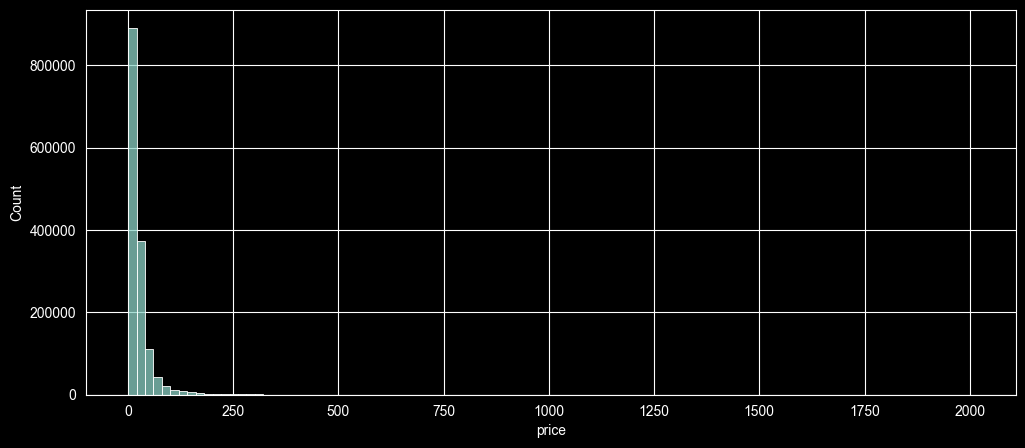

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(mercari_df['price'], bins=100)
plt.show()

**타켓값 로그 변환 후 분포도 확인**

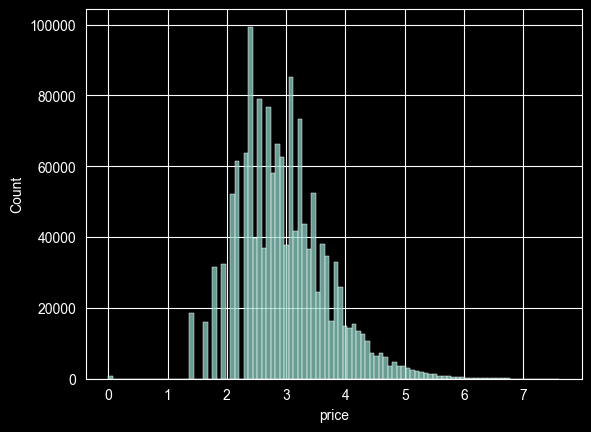

In [101]:
import numpy as np

y_train_df = np.log1p(mercari_df['price'])
sns.histplot(y_train_df, bins=100)
plt.show()


In [102]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head()

0    2.397895
1    3.970292
2    2.397895
3    3.583519
4    3.806662
Name: price, dtype: float64

In [103]:
print(mercari_df['shipping'].value_counts())
print(mercari_df['item_condition_id'].value_counts())

shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [104]:
boolean_cond = mercari_df['item_description'] == 'No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

**category_name이 대/중/소 와 같이 '/' 문자열 기반으로 되어 있음, 이를 개별 컬럼들로 재생성**

In [105]:
mercari_df['category_name']

0                                          Men/Tops/T-shirts
1          Electronics/Computers & Tablets/Components & P...
2                                Women/Tops & Blouses/Blouse
3                         Home/Home Décor/Home Décor Accents
4                                    Women/Jewelry/Necklaces
                                 ...                        
1482530                               Women/Dresses/Mid-Calf
1482531                             Kids/Girls 2T-5T/Dresses
1482532       Sports & Outdoors/Exercise/Fitness accessories
1482533                   Home/Home Décor/Home Décor Accents
1482534                    Women/Women's Accessories/Wallets
Name: category_name, Length: 1482535, dtype: object

In [106]:
result = zip(*[['Women','Tops','T-Shirts'], ['Men','Shoes','Sneakers']])
print(list(result))

[('Women', 'Men'), ('Tops', 'Shoes'), ('T-Shirts', 'Sneakers')]


In [107]:
def split_cat(category_name: str) -> list[str]:
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']


mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))

print('대분류 ======')
print(mercari_df['cat_dae'].value_counts())
print('중분류 ======')
print(mercari_df['cat_jung'].value_counts())
print('소분류 ======')
print(mercari_df['cat_so'].value_counts())


대분류 ======
cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 ======
cat_jung
Athletic Apparel        134383
Makeup                  124624
Tops & Blouses          106960
Shoes                   100452
Jewelry                  61763
                         ...  
Candles                     64
Ceramics and Pottery        57
Dolls and Miniatures        49
Books and Zines             46
Quilts                      31
Name: count, Length: 114, dtype: int64
소분류 ======
cat_so
Pants, Tights, Leggings       60177
Other                         50224
Face                          50171
T-Shirts                      46380
Shoes                         

In [109]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')
mercari_df.drop('category_name', axis=1, inplace=True)

mercari_df.head()

,train_id,name,item_condition_id,brand_name,price,shipping,item_description,cat_dae,cat_jung,cat_so
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Other_Null,2.397895,1,No description yet,Men,Tops,T-shirts
1,1,Razer BlackWidow Chroma Keyboard,3,Razer,3.970292,0,This keyboard is in great condition and works ...,Electronics,Computers & Tablets,Components & Parts
2,2,AVA-VIV Blouse,1,Target,2.397895,1,Adorable top with a hint of lace and a key hol...,Women,Tops & Blouses,Blouse
3,3,Leather Horse Statues,1,Other_Null,3.583519,1,New with tags. Leather horses. Retail for [rm]...,Home,Home Décor,Home Décor Accents
4,4,24K GOLD plated rose,1,Other_Null,3.806662,0,Complete with certificate of authenticity,Women,Jewelry,Necklaces


In [110]:
mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

In [111]:
mercari_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   brand_name         1482535 non-null  object 
 4   price              1482535 non-null  float64
 5   shipping           1482535 non-null  int64  
 6   item_description   1482535 non-null  object 
 7   cat_dae            1482535 non-null  object 
 8   cat_jung           1482535 non-null  object 
 9   cat_so             1482535 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 113.1+ MB


**피처 인코딩과 피처 벡터화**

In [114]:
print(mercari_df['brand_name'].nunique()) # brand name의 유형 건수
mercari_df['brand_name'].value_counts()[:5] # brand name sample 5건

brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64

In [120]:
print(mercari_df['name'].nunique())
mercari_df['name'][:7]

1225273


0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object

In [124]:
pd.set_option('max_colwidth', 200)

print(mercari_df['item_description'].str.len()[:5])
print(mercari_df['item_description'].str.len().mean())
mercari_df['item_description'][:2]


0     18
1    188
2    124
3    173
4     41
Name: item_description, dtype: int64
145.71139703278507


0                                                                                                                                                                              No description yet
1    This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.
Name: item_description, dtype: object

In [127]:
import gc
gc.collect()

0

**name은 Count로, item_description TF-IDF로 피처 벡터화**

In [128]:
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df['name'])

tfidf_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), stop_words='english')
X_descp = tfidf_vectorizer.fit_transform((mercari_df['item_description']))

print(X_name.shape)
print(X_descp.shape)

(1482535, 105757)
(1482535, 50000)


In [150]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
ohe_result = lb.fit_transform([1, 2, 6, 4, 2])
print(type(ohe_result))
print(ohe_result)

lb_sparse = LabelBinarizer(sparse_output=True)
ohe_result_sparse = lb_sparse.fit_transform([1, 2, 6, 4, 2])
print(type(ohe_result_sparse))
print(ohe_result_sparse)


<class 'numpy.ndarray'>
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]
<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (5, 4)>
  Coords	Values
  (0, 0)	1
  (1, 1)	1
  (2, 3)	1
  (3, 2)	1
  (4, 1)	1


In [151]:

# brand_name, item_condition_id, shopping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])


In [152]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand_shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand_shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


In [154]:
import gc
gc.collect()

0

In [ ]:
 # 원-핫 인코딩으로 해도 상관없다.
 # from sklearn.preprocessing import OneHotEncoder
 #
 # oh_encoder = OneHotEncoder()
 # X_brand = oh_encoder.fit_transform((mercari_df['brand_name'].values.reshape(-1, 1)))


**피처 벡터화된 희소 행렬과 원-핫 인코딩된 희소 행렬을 모두 scipy 패키지의 hstack() 함수로 결합**

In [155]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                      X_cat_dae, X_cat_jung, X_cat_so)

# 사이파이 sparse 모듈의 hstack 함수를 이용하여 앞에서 인코딩과 Vectorization 을 수행한 데이터 셋을 모두 결합
X_feature_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_feature_sparse), X_feature_sparse.shape)

# 데이터 셋이 메모리를 많이 차지하므로 사용 용도가 끝났으면 바로 메모리에서 삭제
del X_feature_sparse
gc.collect()


<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


0

#### 릿지 회귀 모델 구축 평가

**rmsle 정의**
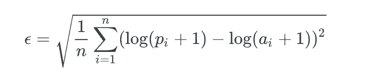

In [158]:
def rmsle(y, y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power((np.log1p(y) - np.log1p(y_pred)), 2)))


def evaluate_org_price(y_test, preds):

    # 원본 데이터는 log1p로 변환되었으므로 exam1으로 원복 필요
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    return rmsle(y_test_exmpm, preds_exmpm)


In [160]:
def moel_train_predict(model, matrix_list):

    X = hstack(matrix_list).tocsr()
    X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'], test_size=0.2, random_state=156)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

In [165]:
linear_model = Ridge(solver='lsqr', fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping,
                      X_cat_dae, X_cat_jung, X_cat_so)

preds, y_test = moel_train_predict(linear_model, sparse_matrix_list)
print('item Description 제외했을 때 rsmle 값 : ', evaluate_org_price(y_test, preds))
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                      X_cat_dae, X_cat_jung, X_cat_so)

linear_preds, y_test = moel_train_predict(linear_model, sparse_matrix_list)
print('item Description 포함 rsmle 값 : ', evaluate_org_price(y_test, preds))

item Description 제외했을 때 rsmle 값 :  0.4983840196992392
item Description 포함 rsmle 값 :  0.4983840196992392


In [163]:
gc.collect()

0

#### LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

In [168]:
from lightgbm import LGBMRegressor


lightgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=25, random_state=156)
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                      X_cat_dae, X_cat_jung, X_cat_so)

lgbm_preds, y_test = moel_train_predict(lightgbm_model, sparse_matrix_list)
print('item Description 포함 rsmle 값 : ', evaluate_org_price(y_test, lgbm_preds))

Exception ignored on calling ctypes callback function <function _log_callback at 0x3d551c7c0>:
Traceback (most recent call last):
  File "/Users/songbeom/PythonWorkSpace/machineLearning/.venv/lib/python3.13/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


Auto-choosing col-wise multi-threading, the overhead of testing was 46.322931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1068421
[LightGBM] [Info] Number of data points in the train set: 1186028, number of used features: 65338
[LightGBM] [Info] Start training from score 2.979514


/Users/songbeom/PythonWorkSpace/machineLearning/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


item Description 포함 rsmle 값 :  0.4791532149209439


In [171]:
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종값', evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종값 0.4577610442992257
